# Baseline Models - Phase 4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
# Load Data

train_df = pd.read_csv("data/processed/train_2010_2022.csv")
test_df = pd.read_csv("data/processed/test_2023_2025.csv")

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (120, 17)
Test: (34, 17)


In [3]:
# Define Features and Targets

numeric_features = [
    "draft_pick_overall",
    "age_on_draft_day",
    "height_inches",
    "weight_lbs",
    "college_games_played",
    "career_yards",
    "career_touchdowns"
]

categorical_features = [
    "position"
]

target_regression = "rookie_total_ppr_points"
target_classification = "fantasy_relevant_binary"

In [4]:
# Create X and y

X_train = train_df[numeric_features + categorical_features]
X_test = test_df[numeric_features + categorical_features]

y_train_reg = train_df[target_regression]
y_test_reg = test_df[target_regression]

y_train_class = train_df[target_classification]
y_test_class = test_df[target_classification]

In [5]:
# Build Preprocessing Pipelines

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [6]:
# Linear Regression Model

linear_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_reg_model.fit(X_train, y_train_reg)

y_pred_reg = linear_reg_model.predict(X_test)

In [7]:
# Regression Metrics

mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("Linear Regression Results")
print("-------------------------")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

Linear Regression Results
-------------------------
MAE:  81.93
RMSE: 97.20


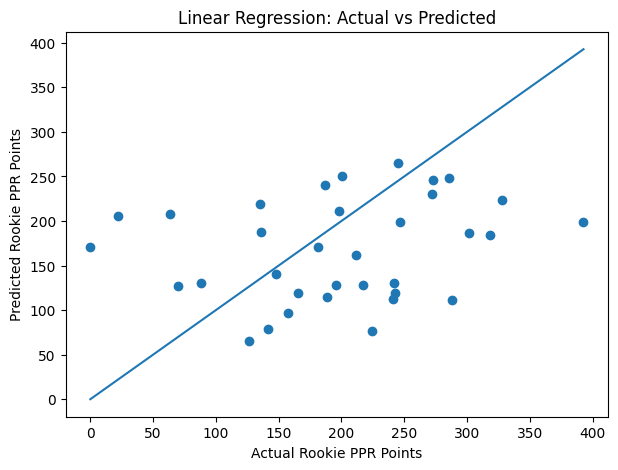

In [8]:
# Actual vs Predicted Plot

plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_reg)
plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()]
)
plt.xlabel("Actual Rookie PPR Points")
plt.ylabel("Predicted Rookie PPR Points")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [9]:
# Logistic Regression Model

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=5000))
])

logistic_model.fit(X_train, y_train_class)

y_pred_class = logistic_model.predict(X_test)
y_pred_prob = logistic_model.predict_proba(X_test)[:, 1]

In [10]:
# Classification Metrics

accuracy = accuracy_score(y_test_class, y_pred_class)
precision = precision_score(y_test_class, y_pred_class, zero_division=0)
recall = recall_score(y_test_class, y_pred_class, zero_division=0)
f1 = f1_score(y_test_class, y_pred_class, zero_division=0)
auc = roc_auc_score(y_test_class, y_pred_prob)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy:  {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}")
print(f"ROC-AUC:   {auc:.2f}")

Logistic Regression Results
---------------------------
Accuracy:  0.50
Precision: 0.56
Recall:    0.28
F1 Score:  0.37
ROC-AUC:   0.64


In [11]:
# Save Baseline Results

baseline_results = pd.DataFrame({
    "model": ["Linear Regression", "Logistic Regression"],
    "task": ["Regression", "Classification"],
    "MAE": [mae, np.nan],
    "RMSE": [rmse, np.nan],
    "Accuracy": [np.nan, accuracy],
    "Precision": [np.nan, precision],
    "Recall": [np.nan, recall],
    "F1": [np.nan, f1],
    "ROC_AUC": [np.nan, auc]
})

baseline_results

,model,task,MAE,RMSE,Accuracy,Precision,Recall,F1,ROC_AUC
0,Linear Regression,Regression,81.930322,97.200703,NaN,NaN,NaN,NaN,NaN
1,Logistic Regression,Classification,NaN,NaN,0.5,0.555556,0.277778,0.37037,0.642361


In [12]:
baseline_results.to_csv("data/processed/baseline_model_results.csv", index=False)